# Decision Trees from Scratch

**Dataset:** Iris (sklearn built-in)  
**Task:** Multiclass classification — 3 species of iris flowers

---

## Overview

A **decision tree** is a supervised learning model that partitions feature space into axis-aligned rectangular regions, making predictions by majority vote (classification) or mean (regression) within each region.

### Building a Tree: CART Algorithm

At each node, CART (Classification and Regression Trees) finds the **best split** by minimizing impurity. For classification we use **Gini impurity**:

$$G(t) = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the fraction of class $k$ samples at node $t$. A node with $G = 0$ is **pure** (all one class). The algorithm greedily searches over all features and thresholds to find the split that minimizes the weighted average impurity of the two child nodes.

### Overfitting and Pruning

Fully grown trees memorize training data. Common controls:
- `max_depth` — limits tree depth
- `min_samples_split` — minimum samples needed to split a node
- `min_samples_leaf` — minimum samples required in a leaf

## 1. Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load and Explore the Dataset

In [3]:
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
target_names  = data.target_names

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {target_names}")
print(f"Class counts: {np.bincount(y)}")

Samples: 150, Features: 4
Classes: ['setosa' 'versicolor' 'virginica']
Class counts: [50 50 50]


In [4]:
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
df.groupby('species').describe().T

species                     setosa  versicolor  virginica
sepal length (cm) count  50.000000   50.000000  50.000000
                  mean    5.006000    5.936000   6.588000
                  std     0.352490    0.516171   0.635880
                  min     4.300000    4.900000   4.900000
                  25%     4.800000    5.600000   6.225000
                  50%     5.000000    5.900000   6.500000
                  75%     5.200000    6.300000   6.900000
                  max     5.800000    7.000000   7.900000
sepal width (cm)  count  50.000000   50.000000  50.000000
                  mean    3.428000    2.770000   2.974000
                  std     0.379064    0.313798   0.322497
                  min     2.300000    2.000000   2.200000
                  25%     3.200000    2.525000   2.800000
                  50%     3.400000    2.800000   3.000000
                  75%     3.675000    3.000000   3.175000
                  max     4.400000    3.400000   3.800000
petal length (cm) count  50.000000   50.000000  50.000000
                  mean    1.462000    4.260000   5.552000
                  std     0.173664    0.469911   0.551895
                  min     1.000000    3.000000   4.500000
                  25%     1.400000    4.000000   5.100000
                  50%     1.500000    4.350000   5.550000
                  75%     1.575000    4.600000   5.875000
                  max     1.900000    5.100000   6.900000
petal width (cm)  count  50.000000   50.000000  50.000000
                  mean    0.246000    1.326000   2.026000
                  std     0.105386    0.197753   0.274650
                  min     0.100000    1.000000   1.400000
                  25%     0.200000    1.200000   1.800000
                  50%     0.200000    1.300000   2.000000
                  75%     0.300000    1.500000   2.300000
                  max     0.600000    1.800000   2.500000

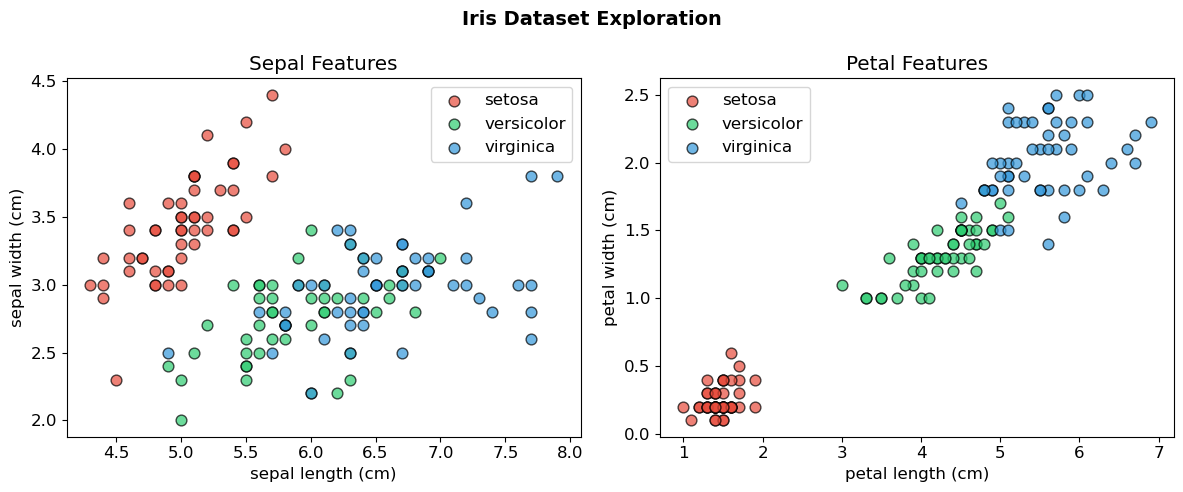

In [5]:
colors = ['#e74c3c', '#2ecc71', '#3498db']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for cls, color, label in zip([0, 1, 2], colors, target_names):
    mask = y == cls
    axes[0].scatter(X[mask, 0], X[mask, 1], c=color, label=label, alpha=0.7, edgecolors='k', s=60)
    axes[1].scatter(X[mask, 2], X[mask, 3], c=color, label=label, alpha=0.7, edgecolors='k', s=60)

axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])
axes[0].set_title('Sepal Features'); axes[0].legend()
axes[1].set_xlabel(feature_names[2]); axes[1].set_ylabel(feature_names[3])
axes[1].set_title('Petal Features'); axes[1].legend()

plt.suptitle('Iris Dataset Exploration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 120 | Test: 30


## 4. Train a Decision Tree

In [7]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt.fit(X_train, y_train)

train_acc = dt.score(X_train, y_train)
test_acc  = dt.score(X_test,  y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

Train accuracy: 0.9917
Test  accuracy: 0.9333


## 5. Visualize the Tree

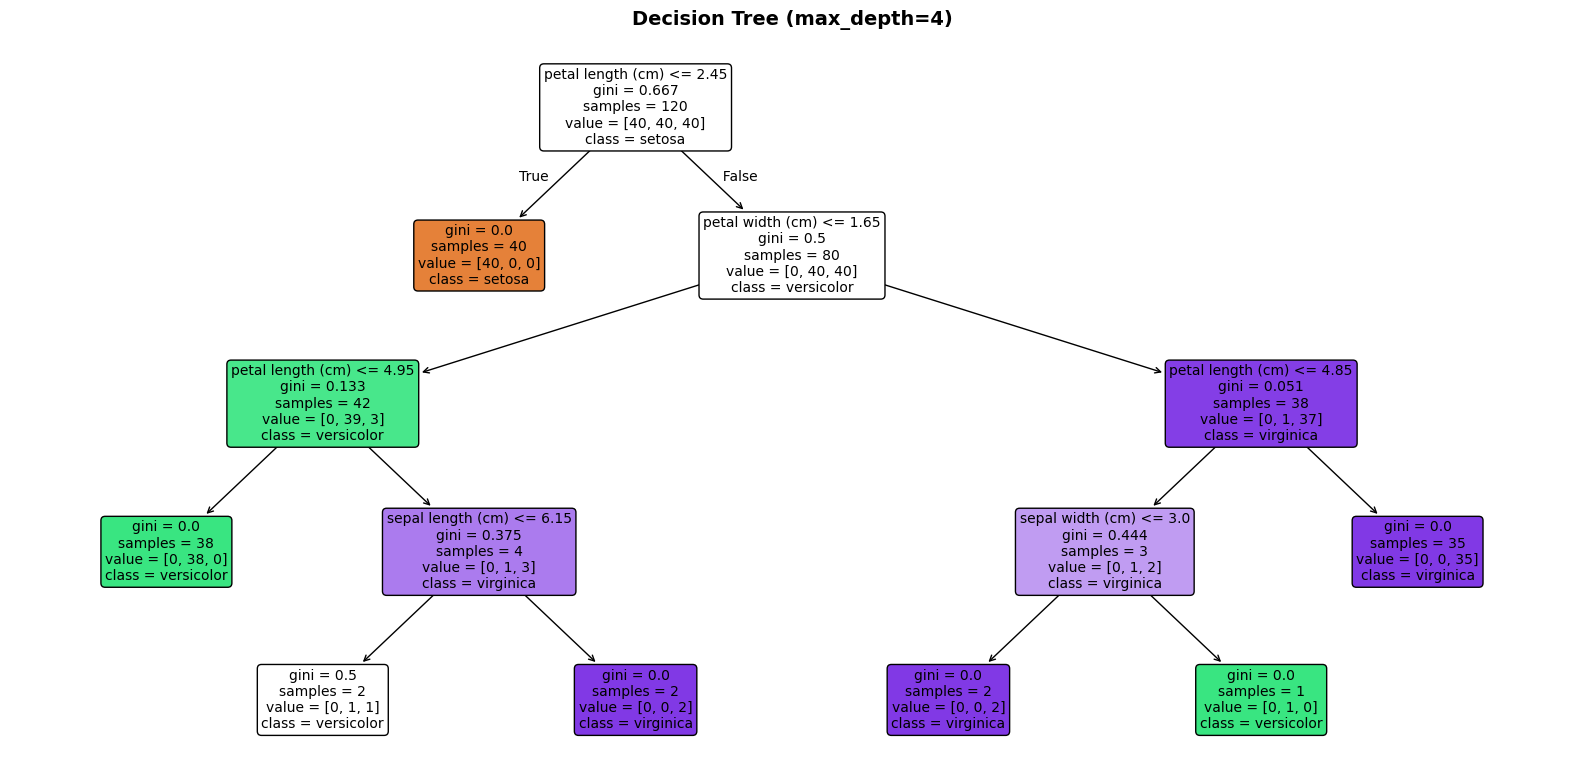

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title('Decision Tree (max_depth=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Effect of Tree Depth on Accuracy

Deeper trees fit training data better but can overfit. We compare train and test accuracy as we vary `max_depth`.

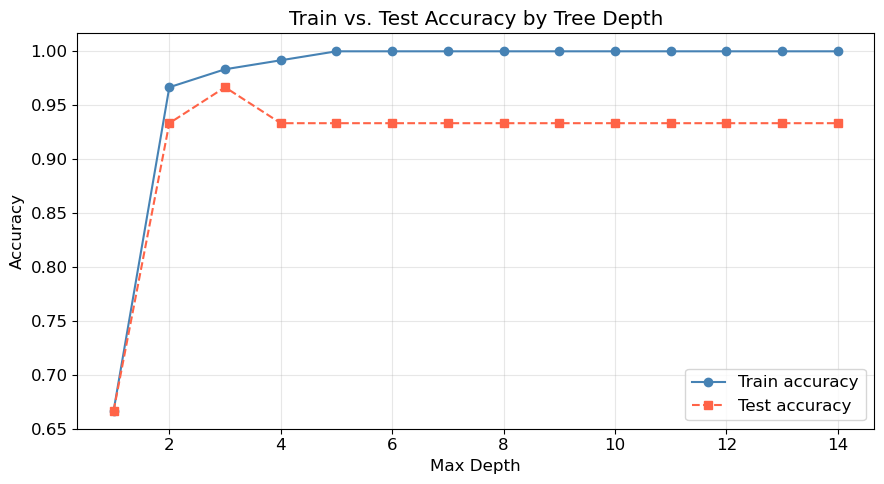

In [9]:
depths = range(1, 15)
train_accs, test_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(clf.score(X_train, y_train))
    test_accs.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, 'o-', color='steelblue', label='Train accuracy')
plt.plot(depths, test_accs,  's--', color='tomato',    label='Test accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy by Tree Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance

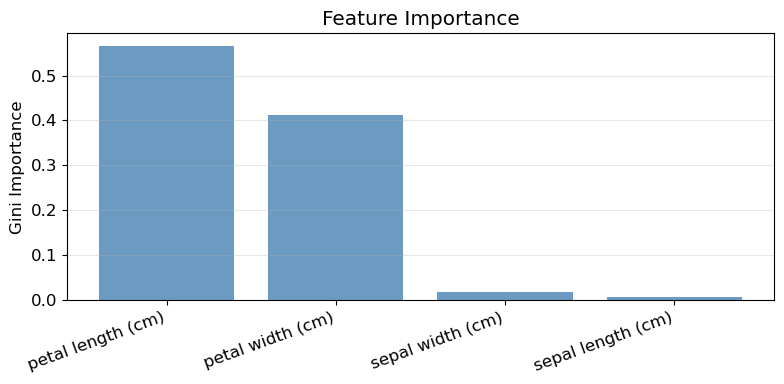

  petal length (cm)             : 0.5656
  petal width (cm)              : 0.4112
  sepal width (cm)              : 0.0169
  sepal length (cm)             : 0.0063


In [10]:
importances = dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(importances)), importances[sorted_idx], color='steelblue', alpha=0.8)
plt.xticks(range(len(importances)), np.array(feature_names)[sorted_idx], rotation=20, ha='right')
plt.ylabel('Gini Importance')
plt.title('Feature Importance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"  {feature_names[i]:30s}: {importances[i]:.4f}")

## 8. Decision Boundary (2D)

We use only the two petal features to visualize the decision boundaries.

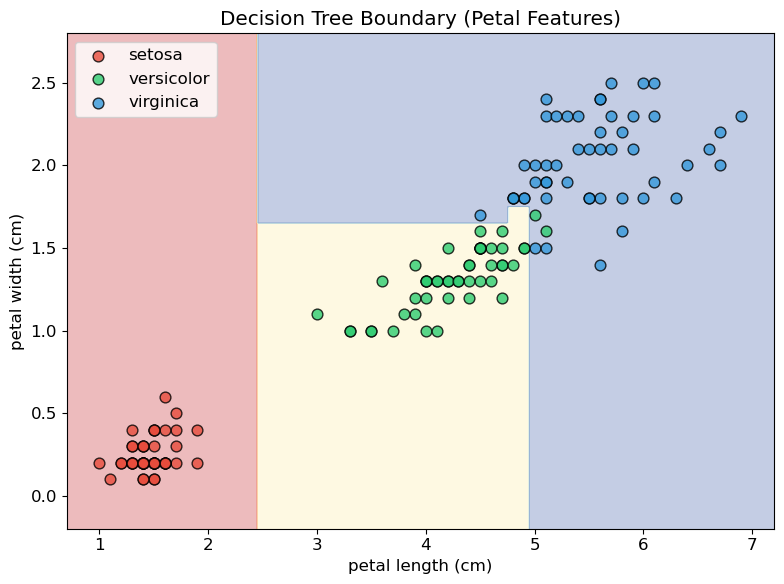

In [11]:
X2 = X[:, 2:4]  # petal length, petal width
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

dt2 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt2.fit(X2_train, y2_train)

x_min, x_max = X2[:, 0].min() - 0.3, X2[:, 0].max() + 0.3
y_min, y_max = X2[:, 1].min() - 0.3, X2[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
for cls, color, label in zip([0, 1, 2], colors, target_names):
    mask = y == cls
    plt.scatter(X2[mask, 0], X2[mask, 1], c=color, label=label,
                edgecolors='k', s=60, alpha=0.8)
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('Decision Tree Boundary (Petal Features)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrix

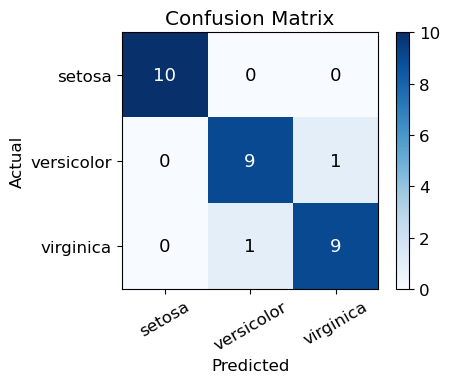

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(target_names, rotation=30)
ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=target_names))

## 10. Summary

### Key Takeaways

- Decision trees partition feature space using **axis-aligned splits** chosen by minimizing Gini impurity.
- **Petal length and width** are the most discriminative features in the Iris dataset.
- Unrestricted trees will achieve 100% training accuracy (**overfitting**) while test accuracy plateaus.
- `max_depth` is the primary hyperparameter for controlling model complexity.
- Trees are highly **interpretable** — you can trace any prediction through a series of if-then rules.
- Decision boundaries are always **rectilinear** (horizontal/vertical lines), which can be limiting for some datasets.